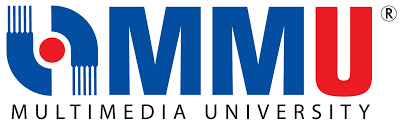

# CDS6344 Social Media Computing  
## Assignment Part 3: Project Code Repository  

### Project Title  
**Aspect-Based Sentiment Analysis of Social Networking App Reviews Using Machine Learning and Transformer Models**

### Group Information  

| Group Number | Student Name | Student ID |
|---|---|---|
| 9 | Venggadanaathan | 1231303562 |
| 9 | Tharraniah Tamilwanan | 1211111799 |

### Dataset  
**AWARE_Social_Networking.csv**

### Notebook 1 Purpose  
This notebook performs the first part of the project pipeline:

1. Dataset loading and inspection  
2. Data cleaning and preparation  
3. Rating-based sentiment label creation  
4. Creation of review-level and aspect-level datasets  
5. Exploratory Data Analysis  
6. Basic visualization of ratings, apps, aspect categories, and sentiment distributions  
7. Exporting cleaned datasets and EDA outputs for Notebook 2, Notebook 3, the final report, presentation, and GitHub repository  

### Main Project Focus  
This project analyses social networking app reviews to understand both:

- **Overall user sentiment** based on 1–5 star ratings  
- **Aspect-level sentiment** based on app features such as usability, reliability, security, cost, efficiency, and effectiveness  

# 1. Assignment and Course Alignment

This project follows the CDS6344 Social Media Computing assignment requirements by developing an end-to-end Natural Language Processing pipeline across three notebooks.

Notebook 1 focuses on dataset loading, cleaning, preprocessing, rating-based sentiment label creation, exploratory data analysis, and visualization.

Opinion mining and ABSA insights are handled in Notebook 2, while model development and evaluation are handled in Notebook 3.

The assignment guideline requires the project to cover sentiment analysis, opinion mining, aspect-based sentiment analysis, model development and evaluation, and visualization. It also expects the use of traditional machine learning, deep learning or transformer-based models, and evaluation metrics such as accuracy, precision, recall, F1-score, and confusion matrices.

This notebook supports the following report sections:

| Report Section | Notebook Support |
|---|---|
| Methodology | Dataset loading, cleaning, preprocessing, label creation |
| Sentiment Analysis | Rating-based sentiment labels from 1–5 ratings |
| Result & Visualization | Rating, app, aspect, and sentiment charts |
| Discussion | Class imbalance, aspect sentiment patterns, data limitations |
| Appendix | Cleaned datasets, output tables, and generated visualizations |

The project also follows the lecture concept of sentiment analysis at three levels:

1. **Document-Level Sentiment Analysis**  
   The full app review is classified using the 1–5 rating column.

2. **Sentence-Level Sentiment Analysis**  
   Individual review sentences are used for aspect-level analysis.

3. **Aspect-Based Sentiment Analysis**  
   Aspect categories and aspect sentiments are used to understand what users like or dislike about specific app features.

# 2. Dataset Description

The selected dataset is **AWARE_Social_Networking.csv**, a social networking app review dataset from the AWARE app review collection.

This dataset is suitable for the assignment because it contains:

| Dataset Feature | Why It Is Important |
|---|---|
| `rating` | Allows rating-based sentiment classification using a 1–5 scale |
| `review` | Full review text for document-level sentiment analysis |
| `sentence` | Sentence-level text for more fine-grained analysis |
| `category` | Aspect category for ABSA |
| `term` | Aspect term mentioned in the sentence |
| `sentiment` | Aspect-level sentiment label |
| `app` | Enables comparison across social networking apps |
| `review_id` | Helps avoid duplicate review-level records |
| `sentence_id` | Helps analyse sentence-level entries |

The dataset is especially relevant to **Social Media Computing** because it focuses on apps such as messaging, communication, calling, and social networking platforms.

# **Install Required Libraries**

Notebook 1 uses standard Python libraries for data preparation, cleaning, and visualization.  

NLTK is used only for stopword handling and lemmatization during text preprocessing.  
Advanced opinion mining, VADER, word clouds, and model training are not included in this notebook because they will be handled in Notebook 2 and Notebook 3.

In [ ]:
# Notebook 1 only requires NLTK for stopword handling and lemmatization.
# NLTK is usually available in Google Colab, but this ensures it is installed.

!pip install nltk -q

print("NLTK installation checked successfully.")

NLTK installation checked successfully.


# **Import Libraries**

In [ ]:
# This cell imports libraries needed for dataset inspection, cleaning,
# exploratory data analysis, visualization, and output saving.
#
# Assignment usage:
# - Supports Methodology section
# - Supports Result & Visualization section
# - Saves clean datasets for Notebook 2 and Notebook 3

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import os
import zipfile
import shutil
import warnings

import nltk
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


# **Set Chart Style**

In [ ]:
# This cell sets a consistent professional visual style for all Notebook 1 charts.
# The goal is to make EDA visualizations report-ready and suitable for PowerPoint slides.

sns.set_theme(style="whitegrid")

# Sentiment colors are kept consistent across all visualizations.
SENTIMENT_COLORS = {
    "Positive": "#2EAD65",
    "Neutral": "#F2B84B",
    "Negative": "#D94F4F",
    "positive": "#2EAD65",
    "negative": "#D94F4F"
}

# Additional colors for app/aspect charts.
MAIN_BLUE = "#2563EB"
MAIN_PURPLE = "#7C3AED"
MAIN_ORANGE = "#F97316"
MAIN_TEAL = "#0D9488"
MAIN_RED = "#DC2626"

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["font.family"] = "DejaVu Sans"

print("Chart style configured successfully.")

Chart style configured successfully.


# **Create Project Folders**

In [ ]:
# This cell creates clean project folders to organize Notebook 1 outputs.
#
# Important:
# Existing results, visualizations, and exports folders are cleared first.
# This prevents old files from previous experimental runs from being included
# in the final Notebook 1 ZIP file.

output_folders = ["results", "visualizations", "exports"]

for folder in output_folders:
    if os.path.exists(folder):
        shutil.rmtree(folder)
    os.makedirs(folder, exist_ok=True)

print("Clean project folders created:")
print("- results/")
print("- visualizations/")
print("- exports/")

Clean project folders created:
- results/
- visualizations/
- exports/


# 3. Dataset Upload

Upload the file:

```text
AWARE_Social_Networking.csv

# **Upload Dataset**

In [ ]:
# This cell uploads the dataset directly into the current Colab runtime.
# It does not upload the file to Google Drive.
#
# After running this cell, choose:
# AWARE_Social_Networking.csv

from google.colab import files

uploaded = files.upload()

Saving AWARE_Social_Networking.csv to AWARE_Social_Networking (1).csv


## **Load Dataset**

In [ ]:
# This cell loads the uploaded CSV file into a pandas DataFrame.
# The DataFrame is named df and will be used throughout Notebook 1.

file_name = "AWARE_Social_Networking.csv"

df = pd.read_csv(file_name)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset shape: (3118, 14)


,domain,app,review_id,sentence_id,title,review,sentence,rating,is_opinion,category,term,from,to,sentiment
0,social networking,whatsapp-messenger,aa65ef9e-27c0-496e-be43-089c1b186ff9,00437139-ab26-4f42-8050-8b464b0a90cd,Need video call through WhatsApp Web,I like WhatsApp to talk to friends that aren’t...,I just drained about 15-20 percent of my phone...,4,True,efficiency,video call,67.0,77.0,negative
1,social networking,discord,fb8b4293-2956-446e-9181-02ed3ceff8ac,007ecad5-2bd1-47de-b94c-4c367b7e2c59,Sharing Screens,"As a mobile user, it is unfortunate that we ca...","On an iPad Pro, I would honestly expect somewa...",4,True,effectiveness,share,52.0,57.0,negative
2,social networking,teamspeak-3,b9c54729-6dea-44da-877e-f1891cf977c6,0097e9d8-fe91-45d1-b66f-3e6cac36459e,Great!!,Does everything the desktop app does! Slight b...,Would be awesome if you could press the volume...,5,True,usability,volume,41.0,47.0,negative
3,social networking,free-tone-calling-texting,a4ffbcdb-2c02-4f95-a5d0-eb716055a709,00a23065-9b78-483b-8bf3-21f1fe59bad8,"Deleted my credits and history, changed my number",I logged in today and my credits and history w...,I've always had trouble with the alerts not wo...,1,True,reliability,phone call,66.0,76.0,negative
4,social networking,discord,86ed17e1-571f-47ba-b405-d2b7991a3a42,0172311b-9191-45f5-a119-8bab09e21358,Wow!,"I’ve been using Skype for years as a gamer, an...",But the mobile recent update just killed it.,5,True,general,recent update,16.0,29.0,negative


# **Display All Columns**

In [ ]:
# This cell displays all column names in the dataset.
# This is important because we need to confirm that the dataset contains:
# rating, review, sentence, category, term, sentiment, app, review_id, and sentence_id.

print("Column names in the dataset:\n")

for index, column in enumerate(df.columns, start=1):
    print(f"{index}. {column}")

Column names in the dataset:

1. domain
2. app
3. review_id
4. sentence_id
5. title
6. review
7. sentence
8. rating
9. is_opinion
10. category
11. term
12. from
13. to
14. sentiment


# **Preview Important Columns**

In [ ]:
# This cell previews the most important columns for this project.
#
# review   -> used for rating-based document-level sentiment classification
# sentence -> used for sentence/aspect-level analysis
# rating   -> used to create document-level sentiment labels
# category -> aspect category for ABSA
# term     -> aspect term for opinion mining
# sentiment -> aspect-level sentiment label
# app      -> used for social networking app comparison

important_columns = [
    "domain",
    "app",
    "review_id",
    "sentence_id",
    "title",
    "review",
    "sentence",
    "rating",
    "is_opinion",
    "category",
    "term",
    "sentiment"
]

available_important_columns = [col for col in important_columns if col in df.columns]

df[available_important_columns].head(10)

,domain,app,review_id,sentence_id,title,review,sentence,rating,is_opinion,category,term,sentiment
0,social networking,whatsapp-messenger,aa65ef9e-27c0-496e-be43-089c1b186ff9,00437139-ab26-4f42-8050-8b464b0a90cd,Need video call through WhatsApp Web,I like WhatsApp to talk to friends that aren’t...,I just drained about 15-20 percent of my phone...,4,True,efficiency,video call,negative
1,social networking,discord,fb8b4293-2956-446e-9181-02ed3ceff8ac,007ecad5-2bd1-47de-b94c-4c367b7e2c59,Sharing Screens,"As a mobile user, it is unfortunate that we ca...","On an iPad Pro, I would honestly expect somewa...",4,True,effectiveness,share,negative
2,social networking,teamspeak-3,b9c54729-6dea-44da-877e-f1891cf977c6,0097e9d8-fe91-45d1-b66f-3e6cac36459e,Great!!,Does everything the desktop app does! Slight b...,Would be awesome if you could press the volume...,5,True,usability,volume,negative
3,social networking,free-tone-calling-texting,a4ffbcdb-2c02-4f95-a5d0-eb716055a709,00a23065-9b78-483b-8bf3-21f1fe59bad8,"Deleted my credits and history, changed my number",I logged in today and my credits and history w...,I've always had trouble with the alerts not wo...,1,True,reliability,phone call,negative
4,social networking,discord,86ed17e1-571f-47ba-b405-d2b7991a3a42,0172311b-9191-45f5-a119-8bab09e21358,Wow!,"I’ve been using Skype for years as a gamer, an...",But the mobile recent update just killed it.,5,True,general,recent update,negative
5,social networking,facebook,b16621ad-5a45-4044-832b-8e641a9ab8cd,0188cb93-2d89-44a1-9f3b-1e6aeed15cec,App is useless,Facebook had become basically unusable for mon...,I’m an IT professional it appears the app is i...,1,True,reliability,volume,negative
6,social networking,facebook,b16621ad-5a45-4044-832b-8e641a9ab8cd,0188cb93-2d89-44a1-9f3b-1e6aeed15cec,App is useless,Facebook had become basically unusable for mon...,I’m an IT professional it appears the app is i...,1,True,reliability,server,negative
7,social networking,whatsapp-messenger,f1e69db3-c442-430e-aa30-4996233a1ea4,01ad25d3-b10d-4ef7-8ecd-03d213d9eae8,Invaluable except for one thing...,I’ve been using WhatsApp for five years now. I...,However... getting added to group chats is so ...,4,True,usability,group chat,negative
8,social networking,whatsapp-messenger,887908b2-3e27-4cd6-9296-b3243647e65f,01fab238-4f7c-4a88-b1f1-8c2a10023686,Love it but add filters,I love this app. Everyone in my family uses it...,I love status updates too.,1,True,general,status update,positive
9,social networking,whatsapp-messenger,84f320fd-34da-4f15-a2b4-a71f6e595d66,02181905-409b-462c-bbc7-64091d949bbd,Not rich in features!,I mean comparing to telegram it lacks some fun...,I mean the update description has been the sam...,3,True,general,version,negative


# **Standardize Column Names for Safety**

In [ ]:
# This cell standardizes column names by:
# - removing leading/trailing spaces
# - replacing spaces with underscores
# - converting column names to lowercase
#
# This prevents coding errors later if a column name has inconsistent formatting.

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("Standardized column names:\n")
print(df.columns.tolist())

Standardized column names:

['domain', 'app', 'review_id', 'sentence_id', 'title', 'review', 'sentence', 'rating', 'is_opinion', 'category', 'term', 'from', 'to', 'sentiment']


# **Check Required Columns**

In [ ]:
# This cell checks whether all required columns exist after standardizing column names.
# If any required column is missing, we must inspect the dataset before continuing.

required_columns = [
    "app",
    "review_id",
    "sentence_id",
    "title",
    "review",
    "sentence",
    "rating",
    "is_opinion",
    "category",
    "term",
    "sentiment"
]

missing_required_columns = [col for col in required_columns if col not in df.columns]

if len(missing_required_columns) == 0:
    print("All required columns are available.")
else:
    print("Missing required columns:")
    print(missing_required_columns)

All required columns are available.


# **Dataset Shape and Unique Counts**

In [ ]:
# This cell summarizes the dataset size.
#
# These values will be useful for the Methodology section of the report:
# - number of rows
# - number of columns
# - number of unique reviews
# - number of unique sentences
# - number of apps

dataset_summary = {
    "Total rows": df.shape[0],
    "Total columns": df.shape[1],
    "Unique reviews": df["review_id"].nunique() if "review_id" in df.columns else np.nan,
    "Unique sentences": df["sentence_id"].nunique() if "sentence_id" in df.columns else np.nan,
    "Unique apps": df["app"].nunique() if "app" in df.columns else np.nan
}

dataset_summary_df = pd.DataFrame(
    dataset_summary.items(),
    columns=["Metric", "Value"]
)

dataset_summary_df

,Metric,Value
0,Total rows,3118
1,Total columns,14
2,Unique reviews,1615
3,Unique sentences,2965
4,Unique apps,6


# **Missing Values Summary**

In [ ]:
# This cell checks missing values in every column.
#
# This helps us decide how to clean the dataset.
# For ABSA, missing values in category, term, or sentiment must be handled carefully.

missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values_df = missing_values.reset_index()
missing_values_df.columns = ["Column", "Missing Values"]

missing_values_df["Missing Percentage"] = (
    missing_values_df["Missing Values"] / len(df) * 100
).round(2)

missing_values_df

,Column,Missing Values,Missing Percentage
0,to,18,0.58
1,from,18,0.58
2,term,18,0.58
3,review_id,0,0.00
4,domain,0,0.00
5,app,0,0.00
6,review,0,0.00
7,title,0,0.00
8,sentence_id,0,0.00
9,sentence,0,0.00


# **Visualize Missing Values**

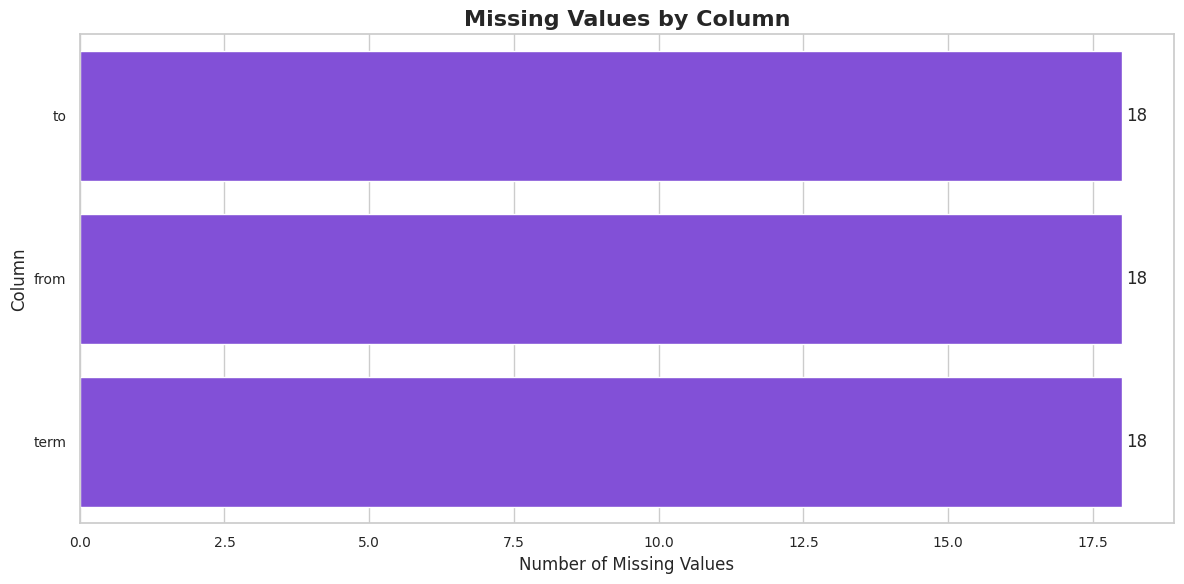

In [ ]:
# This cell creates a missing value chart.
# It will be useful for the Methodology section if any important column has missing data.

missing_plot_df = missing_values_df[missing_values_df["Missing Values"] > 0].copy()

if len(missing_plot_df) > 0:
    plt.figure(figsize=(12, 6))

    ax = sns.barplot(
        data=missing_plot_df,
        x="Missing Values",
        y="Column",
        color=MAIN_PURPLE
    )

    plt.title("Missing Values by Column")
    plt.xlabel("Number of Missing Values")
    plt.ylabel("Column")

    for container in ax.containers:
        ax.bar_label(container, fmt="%d", padding=3)

    plt.tight_layout()
    plt.savefig("visualizations/missing_values_by_column.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No missing values found in the dataset.")

# **Check Duplicate Rows and Duplicate Review/Sentence IDs**

In [ ]:
# This cell checks duplicates at different levels.
#
# Full duplicate rows:
# - exact duplicate records
#
# Duplicate review_id:
# - expected, because one review can contain multiple sentences/aspects
#
# Duplicate sentence_id:
# - may be expected if one sentence contains multiple aspects

duplicate_summary = {
    "Exact duplicate rows": df.duplicated().sum(),
    "Duplicate review_id rows": df["review_id"].duplicated().sum() if "review_id" in df.columns else np.nan,
    "Duplicate sentence_id rows": df["sentence_id"].duplicated().sum() if "sentence_id" in df.columns else np.nan
}

duplicate_summary_df = pd.DataFrame(
    duplicate_summary.items(),
    columns=["Duplicate Type", "Count"]
)

duplicate_summary_df

,Duplicate Type,Count
0,Exact duplicate rows,21
1,Duplicate review_id rows,1503
2,Duplicate sentence_id rows,153


# **Check Rating Values**

In [ ]:
# This cell checks the rating column.
#
# The lecturer requires a rating column out of 5.
# We confirm that the rating values are between 1 and 5.

print("Unique rating values:")
print(sorted(df["rating"].dropna().unique()))

rating_counts = df["rating"].value_counts().sort_index()

rating_counts_df = rating_counts.reset_index()
rating_counts_df.columns = ["Rating", "Count"]

rating_counts_df

Unique rating values:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


,Rating,Count
0,1,794
1,2,332
2,3,493
3,4,639
4,5,860


# **Check App Distribution**

In [ ]:
# This cell checks how many rows are available for each social networking app.
#
# This will support:
# - Dataset Description
# - Result & Visualization
# - Discussion of app-level sentiment patterns

app_counts = df["app"].value_counts().reset_index()
app_counts.columns = ["App", "Row Count"]

app_counts

,App,Row Count
0,whatsapp-messenger,657
1,free-tone-calling-texting,649
2,discord,646
3,facebook,591
4,teamspeak-3,382
5,threema-the-secure-messenger,193


# **Check Aspect Category and Sentiment Distribution**

In [ ]:
# This cell checks the distribution of aspect categories and aspect sentiments.
#
# category  -> shows what app aspects are discussed most
# sentiment -> shows positive and negative aspect-level sentiment balance

category_counts = df["category"].value_counts(dropna=False).reset_index()
category_counts.columns = ["Aspect Category", "Count"]

sentiment_counts = df["sentiment"].value_counts(dropna=False).reset_index()
sentiment_counts.columns = ["Aspect Sentiment", "Count"]

print("Aspect Category Distribution:")
display(category_counts)

print("\nAspect Sentiment Distribution:")
display(sentiment_counts)

Aspect Category Distribution:


,Aspect Category,Count
0,usability,845
1,general,757
2,effectiveness,385
3,efficiency,339
4,security,289
5,cost,195
6,reliability,180
7,enjoyability,94
8,safety,34



Aspect Sentiment Distribution:


,Aspect Sentiment,Count
0,negative,1724
1,positive,1394


# **Check Opinion Column**

In [ ]:
# This cell checks the is_opinion column.
#
# If all rows are opinion rows, the dataset is already cleaned for ABSA.
# If non-opinion rows exist, we will decide whether to use them for opinion detection or remove them for ABSA modelling.

opinion_counts = df["is_opinion"].value_counts(dropna=False).reset_index()
opinion_counts.columns = ["is_opinion", "Count"]

opinion_counts

,is_opinion,Count
0,True,3118


# **Initial Dataset Quality Checklist**

In [ ]:

# This cell creates a clear dataset inspection report.
# It prints the key outputs needed before we continue to cleaning.
#
# Usage for assignment:
# - Helps document dataset understanding for the Methodology section
# - Helps identify missing values, duplicates, class imbalance, and data quality
# - Saves the output as a text file so it can be shared easily
# ============================================================

from io import StringIO
import sys

# Create a text buffer to store the report
report = StringIO()

def write_line(text=""):
    """Write text to both report file and screen."""
    print(text)
    report.write(str(text) + "\n")


write_line("=" * 100)
write_line("CDS6344 GROUP 9 - NOTEBOOK 1 PHASE 1 DATASET INSPECTION REPORT")
write_line("=" * 100)

# ------------------------------------------------------------
# 1. Dataset shape
# ------------------------------------------------------------
write_line("\n1. DATASET SHAPE")
write_line("-" * 100)
write_line(f"Total rows: {df.shape[0]}")
write_line(f"Total columns: {df.shape[1]}")

# ------------------------------------------------------------
# 2. Column list
# ------------------------------------------------------------
write_line("\n2. COLUMN LIST")
write_line("-" * 100)
for i, col in enumerate(df.columns.tolist(), start=1):
    write_line(f"{i}. {col}")

# ------------------------------------------------------------
# 3. Dataset preview
# ------------------------------------------------------------
write_line("\n3. FIRST 5 ROWS PREVIEW")
write_line("-" * 100)
write_line(df.head().to_string())

# ------------------------------------------------------------
# 4. Data types and non-null counts
# ------------------------------------------------------------
write_line("\n4. DATA TYPES AND NON-NULL COUNTS")
write_line("-" * 100)
info_buffer = StringIO()
df.info(buf=info_buffer)
write_line(info_buffer.getvalue())

# ------------------------------------------------------------
# 5. Unique counts
# ------------------------------------------------------------
write_line("\n5. UNIQUE COUNTS")
write_line("-" * 100)

unique_review_count = df["review_id"].nunique() if "review_id" in df.columns else "Column not found"
unique_sentence_count = df["sentence_id"].nunique() if "sentence_id" in df.columns else "Column not found"
unique_app_count = df["app"].nunique() if "app" in df.columns else "Column not found"

write_line(f"Unique reviews: {unique_review_count}")
write_line(f"Unique sentences: {unique_sentence_count}")
write_line(f"Unique apps: {unique_app_count}")

if "app" in df.columns:
    write_line("\nApps included:")
    for app in df["app"].dropna().unique():
        write_line(f"- {app}")

# ------------------------------------------------------------
# 6. Rating distribution
# ------------------------------------------------------------
write_line("\n6. RATING DISTRIBUTION")
write_line("-" * 100)

if "rating" in df.columns:
    rating_distribution = df["rating"].value_counts(dropna=False).sort_index()
    write_line(rating_distribution.to_string())

    write_line("\nRating percentage distribution:")
    rating_percentage = (df["rating"].value_counts(dropna=False, normalize=True).sort_index() * 100).round(2)
    write_line(rating_percentage.to_string())
else:
    write_line("rating column not found.")

# ------------------------------------------------------------
# 7. Aspect sentiment distribution
# ------------------------------------------------------------
write_line("\n7. ASPECT SENTIMENT DISTRIBUTION")
write_line("-" * 100)

if "sentiment" in df.columns:
    sentiment_distribution = df["sentiment"].value_counts(dropna=False)
    write_line(sentiment_distribution.to_string())

    write_line("\nAspect sentiment percentage distribution:")
    sentiment_percentage = (df["sentiment"].value_counts(dropna=False, normalize=True) * 100).round(2)
    write_line(sentiment_percentage.to_string())
else:
    write_line("sentiment column not found.")

# ------------------------------------------------------------
# 8. Aspect category distribution
# ------------------------------------------------------------
write_line("\n8. ASPECT CATEGORY DISTRIBUTION")
write_line("-" * 100)

if "category" in df.columns:
    category_distribution = df["category"].value_counts(dropna=False)
    write_line(category_distribution.to_string())

    write_line("\nAspect category percentage distribution:")
    category_percentage = (df["category"].value_counts(dropna=False, normalize=True) * 100).round(2)
    write_line(category_percentage.to_string())
else:
    write_line("category column not found.")

# ------------------------------------------------------------
# 9. Missing values
# ------------------------------------------------------------
write_line("\n9. MISSING VALUES")
write_line("-" * 100)

missing_values = df.isnull().sum().sort_values(ascending=False)
missing_percentage = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False).round(2)

missing_report = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

write_line(missing_report.to_string())

# ------------------------------------------------------------
# 10. Duplicate summary
# ------------------------------------------------------------
write_line("\n10. DUPLICATE SUMMARY")
write_line("-" * 100)

write_line(f"Exact duplicate rows: {df.duplicated().sum()}")

if "review_id" in df.columns:
    write_line(f"Duplicate review_id rows: {df['review_id'].duplicated().sum()}")
else:
    write_line("review_id column not found.")

if "sentence_id" in df.columns:
    write_line(f"Duplicate sentence_id rows: {df['sentence_id'].duplicated().sum()}")
else:
    write_line("sentence_id column not found.")

# ------------------------------------------------------------
# 11. Opinion label distribution
# ------------------------------------------------------------
write_line("\n11. IS_OPINION DISTRIBUTION")
write_line("-" * 100)

if "is_opinion" in df.columns:
    opinion_distribution = df["is_opinion"].value_counts(dropna=False)
    write_line(opinion_distribution.to_string())

    write_line("\nis_opinion percentage distribution:")
    opinion_percentage = (df["is_opinion"].value_counts(dropna=False, normalize=True) * 100).round(2)
    write_line(opinion_percentage.to_string())
else:
    write_line("is_opinion column not found.")

# ------------------------------------------------------------
# 12. App distribution
# ------------------------------------------------------------
write_line("\n12. APP DISTRIBUTION")
write_line("-" * 100)

if "app" in df.columns:
    app_distribution = df["app"].value_counts(dropna=False)
    write_line(app_distribution.to_string())

    write_line("\nApp percentage distribution:")
    app_percentage = (df["app"].value_counts(dropna=False, normalize=True) * 100).round(2)
    write_line(app_percentage.to_string())
else:
    write_line("app column not found.")

# ------------------------------------------------------------
# 13. Sample rows for manual checking
# ------------------------------------------------------------
write_line("\n13. SAMPLE ROWS FOR MANUAL CHECKING")
write_line("-" * 100)

sample_columns = [
    "app",
    "review_id",
    "sentence_id",
    "title",
    "review",
    "sentence",
    "rating",
    "is_opinion",
    "category",
    "term",
    "sentiment"
]

available_sample_columns = [col for col in sample_columns if col in df.columns]

write_line(df[available_sample_columns].head(10).to_string())

# ------------------------------------------------------------
# 14. Project readiness notes
# ------------------------------------------------------------
write_line("\n14. PROJECT READINESS NOTES")
write_line("-" * 100)

write_line("This report will be used to decide the next cleaning steps.")
write_line("Important checks before continuing:")
write_line("- Confirm rating column uses values from 1 to 5.")
write_line("- Confirm review and sentence columns are available.")
write_line("- Confirm aspect category and sentiment columns are available.")
write_line("- Confirm whether missing values need cleaning.")
write_line("- Confirm whether exact duplicate rows should be removed.")
write_line("- Confirm class imbalance for rating-based and aspect-level sentiment tasks.")

write_line("\n" + "=" * 100)
write_line("END OF PHASE 1 DATASET INSPECTION REPORT")
write_line("=" * 100)

# Save report as a text file
report_text = report.getvalue()

with open("phase1_dataset_inspection_report.txt", "w", encoding="utf-8") as f:
    f.write(report_text)

print("\nReport saved as: phase1_dataset_inspection_report.txt")

CDS6344 GROUP 9 - NOTEBOOK 1 PHASE 1 DATASET INSPECTION REPORT

1. DATASET SHAPE
----------------------------------------------------------------------------------------------------
Total rows: 3118
Total columns: 14

2. COLUMN LIST
----------------------------------------------------------------------------------------------------
1. domain
2. app
3. review_id
4. sentence_id
5. title
6. review
7. sentence
8. rating
9. is_opinion
10. category
11. term
12. from
13. to
14. sentiment

3. FIRST 5 ROWS PREVIEW
----------------------------------------------------------------------------------------------------
              domain                        app                             review_id                           sentence_id                                              title                                                                                                                                                                                                                      

# 4. Data Cleaning and Dataset Preparation

Based on the Phase 1 inspection, the dataset is suitable for this project. The rating column uses values from 1 to 5, and the dataset contains review text, sentence text, aspect categories, aspect terms, and aspect-level sentiment labels.

This phase prepares two cleaned datasets:

1. **Review-Level Dataset**  
   Used for rating-based document-level sentiment classification.

2. **Aspect-Level Dataset**  
   Used for Aspect-Based Sentiment Analysis.

Cleaning decisions:

- Exact duplicate rows are removed.
- Duplicate `review_id` values are not removed from the main dataset because one review may contain multiple sentences or aspects.
- Duplicate `sentence_id` values are not removed from the main dataset because one sentence may contain multiple aspect terms.
- Missing `term` values are filled with `unknown_term`.
- Negation words such as `not`, `no`, and `never` are preserved during text cleaning because they are important for sentiment meaning.

# **Create Cleaning Copy and Remove Exact Duplicates**

In [ ]:
# This cell creates a separate cleaning copy of the original dataset.
# We remove only exact duplicate rows because Phase 1 found 21 exact duplicates.
#
# We do NOT remove duplicate review_id or sentence_id rows here:
# - Duplicate review_id is expected because one review can contain multiple aspect rows.
# - Duplicate sentence_id is expected because one sentence can mention multiple aspects.
#
# Usage for assignment:
# This supports the Methodology section by showing careful data cleaning decisions.

df_clean = df.copy()

print("Original dataset shape:", df_clean.shape)

exact_duplicates_before = df_clean.duplicated().sum()
print("Exact duplicate rows before cleaning:", exact_duplicates_before)

df_clean = df_clean.drop_duplicates().reset_index(drop=True)

exact_duplicates_after = df_clean.duplicated().sum()
print("Dataset shape after removing exact duplicate rows:", df_clean.shape)
print("Exact duplicate rows after cleaning:", exact_duplicates_after)

Original dataset shape: (3118, 14)
Exact duplicate rows before cleaning: 21
Dataset shape after removing exact duplicate rows: (3097, 14)
Exact duplicate rows after cleaning: 0


# **Fill Missing Aspect Terms**

In [ ]:
# This cell handles the 18 missing values in the term column.
#
# We do not drop these rows because:
# - The missing term count is very small.
# - The rows still contain useful sentence, category, rating, and sentiment information.
# - Dropping them would unnecessarily reduce ABSA training data.
#
# Missing aspect terms are replaced with "unknown_term".

missing_terms_before = df_clean["term"].isnull().sum()

df_clean["term"] = df_clean["term"].fillna("unknown_term")

missing_terms_after = df_clean["term"].isnull().sum()

print("Missing terms before filling:", missing_terms_before)
print("Missing terms after filling:", missing_terms_after)

Missing terms before filling: 18
Missing terms after filling: 0


# **Normalize Text Labels**

In [ ]:
text_label_columns = ["domain", "app", "category", "sentiment"]

for_col_check = []
for col in text_label_columns:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype(str).str.strip().str.lower()
        for_col_check.append(col)

print("Standardized columns:")
print(for_col_check)

print("\nUnique sentiment labels after standardization:")
print(df_clean["sentiment"].unique())

print("\nUnique aspect categories after standardization:")
print(df_clean["category"].unique())

Standardized columns:
['domain', 'app', 'category', 'sentiment']

Unique sentiment labels after standardization:
['negative' 'positive']

Unique aspect categories after standardization:
['efficiency' 'effectiveness' 'usability' 'reliability' 'general'
 'security' 'cost' 'safety' 'enjoyability']


# **Create Rating-Based Sentiment Labels**

In [ ]:
# This cell creates document-level sentiment labels from the 1–5 rating column.
#
# Mapping:
# 1–2 stars = Negative
# 3 stars   = Neutral
# 4–5 stars = Positive
#
# Usage for assignment:
# This satisfies the lecturer's requirement for a rating column out of 5
# and supports the rating-based document-level sentiment classification task.

def create_rating_sentiment(rating):
    if rating in [1, 2]:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    elif rating in [4, 5]:
        return "Positive"
    else:
        return "Unknown"

df_clean["rating_sentiment"] = df_clean["rating"].apply(create_rating_sentiment)

print("Rating-based sentiment distribution at row level:")
print(df_clean["rating_sentiment"].value_counts())

print("\nRating and rating-based sentiment preview:")
df_clean[["rating", "rating_sentiment", "sentiment"]].head(10)

Rating-based sentiment distribution at row level:
rating_sentiment
Positive    1488
Negative    1120
Neutral      489
Name: count, dtype: int64

Rating and rating-based sentiment preview:


,rating,rating_sentiment,sentiment
0,4,Positive,negative
1,4,Positive,negative
2,5,Positive,negative
3,1,Negative,negative
4,5,Positive,negative
5,1,Negative,negative
6,1,Negative,negative
7,4,Positive,negative
8,1,Negative,positive
9,3,Neutral,negative


# **Text Cleaning Setup**

In [ ]:
# This cell prepares the text cleaning tools.
#
# Important decision:
# Negation words are preserved because they change sentiment meaning.
#
# Example:
# "not good" should not become "good"
# "never works" should not lose "never"
#
# This avoids the earlier issue where sentiment meaning became confused after cleaning.

stop_words = set(stopwords.words("english"))

negation_words = {
    "no", "not", "nor", "never", "none", "cannot", "can't", "dont", "don't",
    "doesnt", "doesn't", "didnt", "didn't", "isnt", "isn't", "wasnt", "wasn't",
    "werent", "weren't", "wont", "won't", "wouldnt", "wouldn't", "shouldnt",
    "shouldn't", "couldnt", "couldn't", "without", "hardly", "barely"
}

custom_stop_words = stop_words - negation_words

lemmatizer = WordNetLemmatizer()

print("Total default stopwords:", len(stop_words))
print("Total custom stopwords after keeping negations:", len(custom_stop_words))
print("Negation words preserved:", sorted(list(negation_words))[:10], "...")

Total default stopwords: 198
Total custom stopwords after keeping negations: 185
Negation words preserved: ['barely', "can't", 'cannot', "couldn't", 'couldnt', "didn't", 'didnt', "doesn't", 'doesnt', "don't"] ...


# **Define Text Cleaning Functions**

In [ ]:
# This cell defines two text cleaning functions.
#
# 1. basic_clean_text:
#    - Light cleaning
#    - Keeps more natural sentence structure
#    - Useful for lexicon-based opinion mining and readable outputs
#
# 2. ml_clean_text:
#    - Stronger cleaning
#    - Removes stopwords except negations
#    - Applies lemmatization
#    - Useful for TF-IDF traditional machine learning models
#
# Both functions preserve negation meaning as much as possible.

def normalize_apostrophes(text):
    """Normalize curly apostrophes and common contractions."""
    text = str(text)
    text = text.replace("’", "'").replace("‘", "'").replace("`", "'")
    text = re.sub(r"n't\b", " not", text)
    text = re.sub(r"\bcan't\b", "cannot", text)
    text = re.sub(r"\bwon't\b", "will not", text)
    return text


def basic_clean_text(text):
    """
    Light text cleaning for readable analysis.
    Keeps most words and preserves negation cues.
    """
    text = normalize_apostrophes(text)
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def ml_clean_text(text):
    """
    Stronger text cleaning for traditional ML.
    Removes stopwords except negation words and lemmatizes tokens.
    """
    text = basic_clean_text(text)
    words = text.split()
    words = [word for word in words if word not in custom_stop_words]
    words = [lemmatizer.lemmatize(word) for word in words]
    return " ".join(words)

# **Apply Text Cleaning**

In [ ]:
# This cell applies text cleaning to both review-level and sentence-level text.
#
# New columns created:
# - basic_clean_review
# - ml_clean_review
# - basic_clean_sentence
# - ml_clean_sentence
#
# Usage for assignment:
# These cleaned text columns support preprocessing in the Methodology section
# and will be used later for EDA, opinion mining, and modelling.

df_clean["basic_clean_review"] = df_clean["review"].apply(basic_clean_text)
df_clean["ml_clean_review"] = df_clean["review"].apply(ml_clean_text)

df_clean["basic_clean_sentence"] = df_clean["sentence"].apply(basic_clean_text)
df_clean["ml_clean_sentence"] = df_clean["sentence"].apply(ml_clean_text)

print("Text cleaning completed.")

df_clean[
    [
        "review",
        "basic_clean_review",
        "ml_clean_review",
        "sentence",
        "basic_clean_sentence",
        "ml_clean_sentence"
    ]
].head(3)

Text cleaning completed.


,review,basic_clean_review,ml_clean_review,sentence,basic_clean_sentence,ml_clean_sentence
0,I like WhatsApp to talk to friends that aren’t...,i like whatsapp to talk to friends that are no...,like whatsapp talk friend not america recently...,I just drained about 15-20 percent of my phone...,i just drained about percent of my phone batte...,drained percent phone battery video call bet l...
1,"As a mobile user, it is unfortunate that we ca...",as a mobile user it is unfortunate that we can...,mobile user unfortunate cannot share screen mo...,"On an iPad Pro, I would honestly expect somewa...",on an ipad pro i would honestly expect someway...,ipad pro would honestly expect someway share s...
2,Does everything the desktop app does! Slight b...,does everything the desktop app does slight bu...,everything desktop app slight bug switching wi...,Would be awesome if you could press the volume...,would be awesome if you could press the volume...,would awesome could press volume button activa...


# **Create Length Features**

In [ ]:
# This cell creates review and sentence length features.
#
# These features are useful for:
# - Exploratory Data Analysis
# - Understanding whether positive/negative reviews differ in length
# - Supporting the Result & Visualization section

df_clean["review_word_count"] = df_clean["basic_clean_review"].apply(lambda x: len(str(x).split()))
df_clean["sentence_word_count"] = df_clean["basic_clean_sentence"].apply(lambda x: len(str(x).split()))

print("Length features created.")

df_clean[
    [
        "review_word_count",
        "sentence_word_count",
        "rating_sentiment",
        "sentiment"
    ]
].describe()

Length features created.


,review_word_count,sentence_word_count
count,3097.000000,3097.000000
mean,120.582822,16.765257
std,67.123563,6.071983
min,4.000000,3.000000
25%,64.000000,12.000000
50%,113.000000,17.000000
75%,173.000000,21.000000
max,421.000000,33.000000


# **Create Review-Level Dataset**

In [ ]:
# This cell creates the review-level dataset.
#
# One review can appear multiple times in the original dataset because it may contain
# multiple sentences or multiple aspects.
#
# For document-level sentiment classification, we need one row per review_id.
# Therefore, we keep the first row for each review_id.
#
# This dataset will be used in Notebook 2 for rating-based sentiment classification.

review_level_columns = [
    "domain",
    "app",
    "review_id",
    "title",
    "review",
    "rating",
    "rating_sentiment",
    "basic_clean_review",
    "ml_clean_review",
    "review_word_count"
]

review_level_df = (
    df_clean[review_level_columns]
    .drop_duplicates(subset=["review_id"])
    .reset_index(drop=True)
)

print("Review-level dataset created.")
print("Shape:", review_level_df.shape)

print("\nRating-based sentiment distribution in review-level dataset:")
print(review_level_df["rating_sentiment"].value_counts())

review_level_df.head()

Review-level dataset created.
Shape: (1615, 10)

Rating-based sentiment distribution in review-level dataset:
rating_sentiment
Positive    804
Negative    551
Neutral     260
Name: count, dtype: int64


,domain,app,review_id,title,review,rating,rating_sentiment,basic_clean_review,ml_clean_review,review_word_count
0,social networking,whatsapp-messenger,aa65ef9e-27c0-496e-be43-089c1b186ff9,Need video call through WhatsApp Web,I like WhatsApp to talk to friends that aren’t...,4,Positive,i like whatsapp to talk to friends that are no...,like whatsapp talk friend not america recently...,96
1,social networking,discord,fb8b4293-2956-446e-9181-02ed3ceff8ac,Sharing Screens,"As a mobile user, it is unfortunate that we ca...",4,Positive,as a mobile user it is unfortunate that we can...,mobile user unfortunate cannot share screen mo...,170
2,social networking,teamspeak-3,b9c54729-6dea-44da-877e-f1891cf977c6,Great!!,Does everything the desktop app does! Slight b...,5,Positive,does everything the desktop app does slight bu...,everything desktop app slight bug switching wi...,49
3,social networking,free-tone-calling-texting,a4ffbcdb-2c02-4f95-a5d0-eb716055a709,"Deleted my credits and history, changed my number",I logged in today and my credits and history w...,1,Negative,i logged in today and my credits and history w...,logged today credit history gone number change...,197
4,social networking,discord,86ed17e1-571f-47ba-b405-d2b7991a3a42,Wow!,"I’ve been using Skype for years as a gamer, an...",5,Positive,i ve been using skype for years as a gamer and...,using skype year gamer liked mobile recent upd...,136


# **Create Aspect-Level Dataset**

In [ ]:
# This cell creates the aspect-level dataset.
#
# The aspect-level dataset is the main dataset for ABSA.
# It uses sentence-level text, aspect category, aspect term, and aspect sentiment.
#
# Since Phase 1 showed is_opinion is True for all rows, all rows are opinion rows.
# We still keep the condition for safety.
#
# This dataset will be used in Notebook 2 for aspect-level sentiment classification.

aspect_level_columns = [
    "domain",
    "app",
    "review_id",
    "sentence_id",
    "title",
    "review",
    "sentence",
    "rating",
    "rating_sentiment",
    "is_opinion",
    "category",
    "term",
    "from",
    "to",
    "sentiment",
    "basic_clean_sentence",
    "ml_clean_sentence",
    "sentence_word_count"
]

aspect_level_df = df_clean[aspect_level_columns].copy()

aspect_level_df = aspect_level_df[
    (aspect_level_df["is_opinion"] == True) &
    (aspect_level_df["sentiment"].isin(["positive", "negative"]))
].reset_index(drop=True)

print("Aspect-level dataset created.")
print("Shape:", aspect_level_df.shape)

print("\nAspect sentiment distribution:")
print(aspect_level_df["sentiment"].value_counts())

aspect_level_df.head()

Aspect-level dataset created.
Shape: (3097, 18)

Aspect sentiment distribution:
sentiment
negative    1715
positive    1382
Name: count, dtype: int64


,domain,app,review_id,sentence_id,title,review,sentence,rating,rating_sentiment,is_opinion,category,term,from,to,sentiment,basic_clean_sentence,ml_clean_sentence,sentence_word_count
0,social networking,whatsapp-messenger,aa65ef9e-27c0-496e-be43-089c1b186ff9,00437139-ab26-4f42-8050-8b464b0a90cd,Need video call through WhatsApp Web,I like WhatsApp to talk to friends that aren’t...,I just drained about 15-20 percent of my phone...,4,Positive,True,efficiency,video call,67.0,77.0,negative,i just drained about percent of my phone batte...,drained percent phone battery video call bet l...,24
1,social networking,discord,fb8b4293-2956-446e-9181-02ed3ceff8ac,007ecad5-2bd1-47de-b94c-4c367b7e2c59,Sharing Screens,"As a mobile user, it is unfortunate that we ca...","On an iPad Pro, I would honestly expect somewa...",4,Positive,True,effectiveness,share,52.0,57.0,negative,on an ipad pro i would honestly expect someway...,ipad pro would honestly expect someway share s...,18
2,social networking,teamspeak-3,b9c54729-6dea-44da-877e-f1891cf977c6,0097e9d8-fe91-45d1-b66f-3e6cac36459e,Great!!,Does everything the desktop app does! Slight b...,Would be awesome if you could press the volume...,5,Positive,True,usability,volume,41.0,47.0,negative,would be awesome if you could press the volume...,would awesome could press volume button activa...,25
3,social networking,free-tone-calling-texting,a4ffbcdb-2c02-4f95-a5d0-eb716055a709,00a23065-9b78-483b-8bf3-21f1fe59bad8,"Deleted my credits and history, changed my number",I logged in today and my credits and history w...,I've always had trouble with the alerts not wo...,1,Negative,True,reliability,phone call,66.0,76.0,negative,i ve always had trouble with the alerts not wo...,always trouble alert not working get phone cal...,18
4,social networking,discord,86ed17e1-571f-47ba-b405-d2b7991a3a42,0172311b-9191-45f5-a119-8bab09e21358,Wow!,"I’ve been using Skype for years as a gamer, an...",But the mobile recent update just killed it.,5,Positive,True,general,recent update,16.0,29.0,negative,but the mobile recent update just killed it,mobile recent update killed,8


# **Create Model Input Text for Aspect-Level Task**

In [ ]:
# This cell creates a combined input field for the ABSA model.
#
# Instead of using sentence text alone, we combine:
# sentence + aspect category + aspect term
#
# This helps the model understand which aspect is being judged.
#
# Example:
# Sentence: "The app crashes often."
# Category: reliability
# Term: app
#
# Model input:
# "the app crashes often [SEP] reliability [SEP] app"

aspect_level_df["aspect_model_input"] = (
    aspect_level_df["basic_clean_sentence"] +
    " [SEP] " +
    aspect_level_df["category"].astype(str) +
    " [SEP] " +
    aspect_level_df["term"].astype(str)
)

aspect_level_df["aspect_model_input_ml"] = aspect_level_df["aspect_model_input"].apply(ml_clean_text)

print("Aspect model input created.")

aspect_level_df[
    [
        "sentence",
        "category",
        "term",
        "sentiment",
        "aspect_model_input"
    ]
].head(10)

Aspect model input created.


,sentence,category,term,sentiment,aspect_model_input
0,I just drained about 15-20 percent of my phone...,efficiency,video call,negative,i just drained about percent of my phone batte...
1,"On an iPad Pro, I would honestly expect somewa...",effectiveness,share,negative,on an ipad pro i would honestly expect someway...
2,Would be awesome if you could press the volume...,usability,volume,negative,would be awesome if you could press the volume...
3,I've always had trouble with the alerts not wo...,reliability,phone call,negative,i ve always had trouble with the alerts not wo...
4,But the mobile recent update just killed it.,general,recent update,negative,but the mobile recent update just killed it [S...
5,I’m an IT professional it appears the app is i...,reliability,volume,negative,i m an it professional it appears the app is i...
6,I’m an IT professional it appears the app is i...,reliability,server,negative,i m an it professional it appears the app is i...
7,However... getting added to group chats is so ...,usability,group chat,negative,however getting added to group chats is so ann...
8,I love status updates too.,general,status update,positive,i love status updates too [SEP] general [SEP] ...
9,I mean the update description has been the sam...,general,version,negative,i mean the update description has been the sam...


# **Save Cleaned Datasets**

In [ ]:
# This cell saves the cleaned datasets for Notebook 2.
#
# Output files:
# - review_level_social_reviews.csv
# - aspect_level_social_reviews.csv
#
# These files will be uploaded or loaded in Notebook 2 for modelling.

review_level_path = "results/review_level_social_reviews.csv"
aspect_level_path = "results/aspect_level_social_reviews.csv"

review_level_df.to_csv(review_level_path, index=False)
aspect_level_df.to_csv(aspect_level_path, index=False)

print("Cleaned datasets saved successfully:")
print(review_level_path)
print(aspect_level_path)

Cleaned datasets saved successfully:
results/review_level_social_reviews.csv
results/aspect_level_social_reviews.csv


# 5. Exploratory Data Analysis and Visualization

This phase generates visualizations for the final report and PowerPoint presentation.

The goals of this phase are:

1. Analyse the 1–5 rating distribution.
2. Analyse rating-based document-level sentiment.
3. Analyse app-wise review distribution.
4. Analyse aspect category distribution.
5. Analyse aspect-level sentiment distribution.
6. Analyse aspect sentiment across different apps and categories.
7. Save all charts as high-resolution PNG files for the report and slides.

These outputs will be used mainly in:

- Section 4: Methodology
- Section 5: Sentiment Analysis
- Section 7: Result & Visualization
- Section 8: Discussion

# **Helper Function for Bar Labels**

In [ ]:
# This helper function adds value labels on top of bar charts.
# It makes the visualizations easier to understand in the report and presentation.

def add_bar_labels(ax, fmt="{:.0f}", padding=3):
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, padding=padding, fontsize=9)

# **Rating Distribution Table**

In [ ]:
# This cell creates a rating distribution table from the review-level dataset.
#
# We use review_level_df instead of df_clean because rating is a document-level property.
# This avoids counting the same review multiple times.

rating_summary = review_level_df["rating"].value_counts().sort_index().reset_index()
rating_summary.columns = ["Rating", "Count"]

rating_summary["Percentage"] = (
    rating_summary["Count"] / rating_summary["Count"].sum() * 100
).round(2)

rating_summary.to_csv("results/rating_distribution_summary.csv", index=False)

rating_summary

,Rating,Count,Percentage
0,1,396,24.52
1,2,155,9.60
2,3,260,16.10
3,4,313,19.38
4,5,491,30.40


# **Rating Distribution Chart**

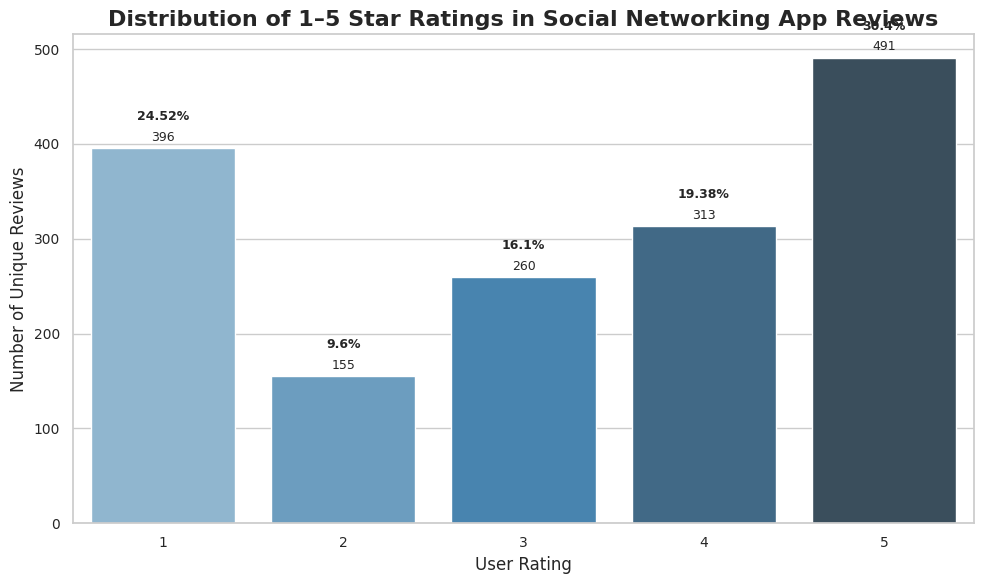

In [ ]:
# This chart shows the distribution of 1–5 star ratings.
#
# Assignment usage:
# - Shows that the dataset contains the required rating column out of 5.
# - Supports the dataset description and sentiment label creation explanation.

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=rating_summary,
    x="Rating",
    y="Count",
    palette="Blues_d"
)

plt.title("Distribution of 1–5 Star Ratings in Social Networking App Reviews")
plt.xlabel("User Rating")
plt.ylabel("Number of Unique Reviews")

add_bar_labels(ax)

for i, row in rating_summary.iterrows():
    ax.text(
        i,
        row["Count"] + rating_summary["Count"].max() * 0.06,
        f'{row["Percentage"]}%',
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
plt.savefig("visualizations/rating_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# **Rating-Based Sentiment Distribution Table**

In [ ]:
# This cell summarizes document-level sentiment created from rating values.
#
# Mapping:
# 1–2 = Negative
# 3   = Neutral
# 4–5 = Positive
#
# This is used for rating-based document-level sentiment analysis.

rating_sentiment_order = ["Positive", "Neutral", "Negative"]

rating_sentiment_summary = (
    review_level_df["rating_sentiment"]
    .value_counts()
    .reindex(rating_sentiment_order)
    .reset_index()
)

rating_sentiment_summary.columns = ["Rating Sentiment", "Count"]

rating_sentiment_summary["Percentage"] = (
    rating_sentiment_summary["Count"] / rating_sentiment_summary["Count"].sum() * 100
).round(2)

rating_sentiment_summary.to_csv("results/rating_sentiment_summary.csv", index=False)

rating_sentiment_summary

,Rating Sentiment,Count,Percentage
0,Positive,804,49.78
1,Neutral,260,16.10
2,Negative,551,34.12


# **Rating-Based Sentiment Distribution Chart**

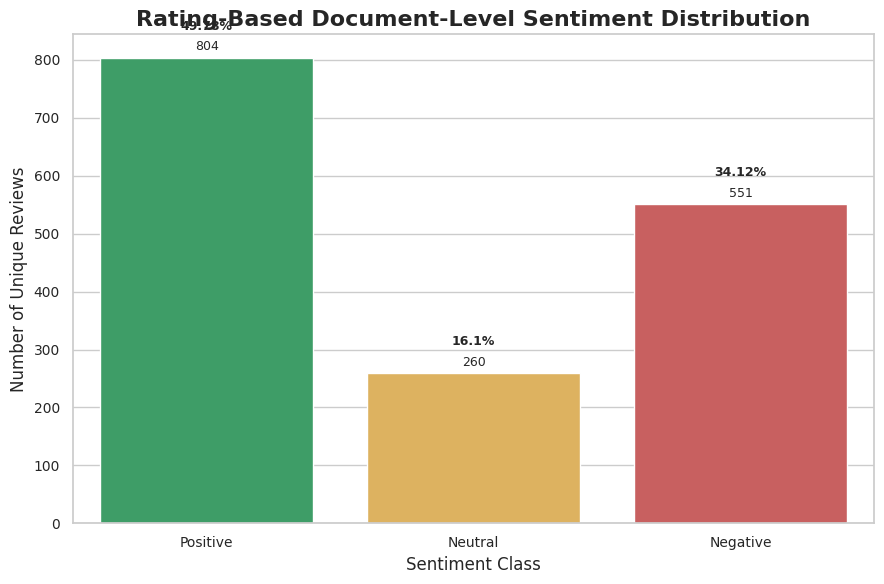

In [ ]:
# This chart shows the distribution of rating-based sentiment classes.
#
# Assignment usage:
# - Supports the Sentiment Analysis section.
# - Shows class imbalance clearly.
# - Explains why macro F1-score and weighted F1-score will be used in Notebook 2.

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=rating_sentiment_summary,
    x="Rating Sentiment",
    y="Count",
    palette=[
        SENTIMENT_COLORS["Positive"],
        SENTIMENT_COLORS["Neutral"],
        SENTIMENT_COLORS["Negative"]
    ]
)

plt.title("Rating-Based Document-Level Sentiment Distribution")
plt.xlabel("Sentiment Class")
plt.ylabel("Number of Unique Reviews")

add_bar_labels(ax)

for i, row in rating_sentiment_summary.iterrows():
    ax.text(
        i,
        row["Count"] + rating_sentiment_summary["Count"].max() * 0.06,
        f'{row["Percentage"]}%',
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
plt.savefig("visualizations/rating_based_sentiment_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# **App Distribution Table**

In [ ]:
# This cell summarizes the number of unique reviews for each social networking app.
#
# We use the review-level dataset so each review is counted once.

app_summary = review_level_df["app"].value_counts().reset_index()
app_summary.columns = ["App", "Review Count"]

app_summary["Percentage"] = (
    app_summary["Review Count"] / app_summary["Review Count"].sum() * 100
).round(2)

app_summary.to_csv("results/app_distribution_summary.csv", index=False)

app_summary

,App,Review Count,Percentage
0,free-tone-calling-texting,471,29.16
1,whatsapp-messenger,273,16.90
2,discord,272,16.84
3,facebook,271,16.78
4,teamspeak-3,234,14.49
5,threema-the-secure-messenger,94,5.82


# **App Distribution Chart**

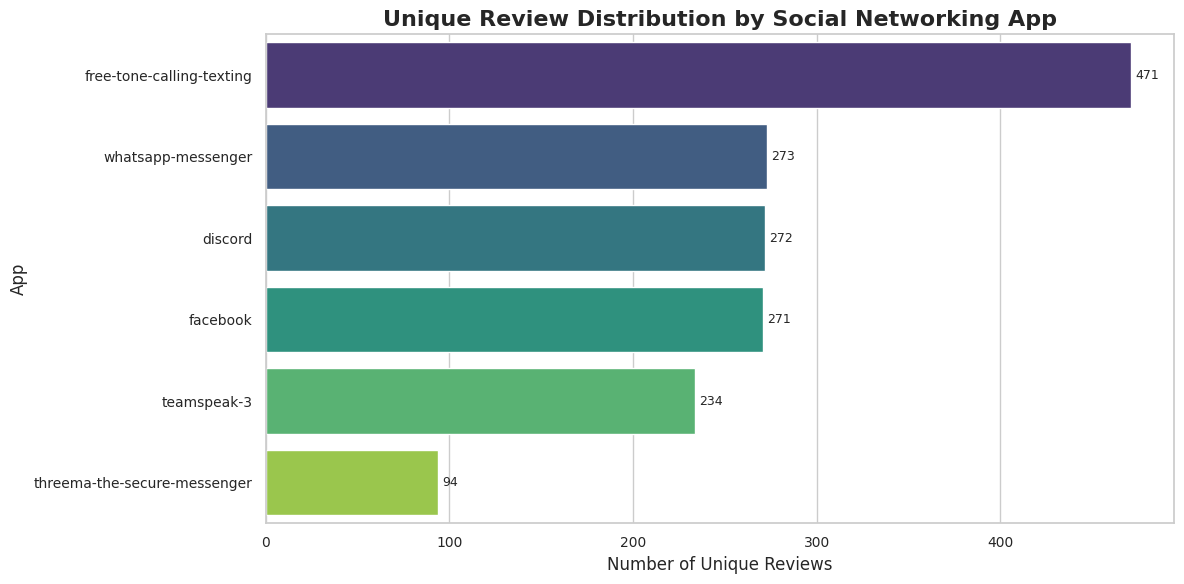

In [ ]:
# This chart shows how many unique reviews are available for each app.
#
# Assignment usage:
# - Supports dataset description.
# - Helps compare social networking apps in later discussion.

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=app_summary,
    x="Review Count",
    y="App",
    palette="viridis"
)

plt.title("Unique Review Distribution by Social Networking App")
plt.xlabel("Number of Unique Reviews")
plt.ylabel("App")

add_bar_labels(ax)

plt.tight_layout()
plt.savefig("visualizations/app_review_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# **Aspect Category Distribution Table**

In [ ]:
# This cell summarizes how often each aspect category appears.
#
# This is central to ABSA because it shows what users talk about most.

aspect_category_summary = aspect_level_df["category"].value_counts().reset_index()
aspect_category_summary.columns = ["Aspect Category", "Count"]

aspect_category_summary["Percentage"] = (
    aspect_category_summary["Count"] / aspect_category_summary["Count"].sum() * 100
).round(2)

aspect_category_summary.to_csv("results/aspect_category_summary.csv", index=False)

aspect_category_summary

,Aspect Category,Count,Percentage
0,usability,842,27.19
1,general,756,24.41
2,effectiveness,379,12.24
3,efficiency,337,10.88
4,security,284,9.17
5,cost,194,6.26
6,reliability,178,5.75
7,enjoyability,94,3.04
8,safety,33,1.07


# **Aspect Category Distribution Chart**

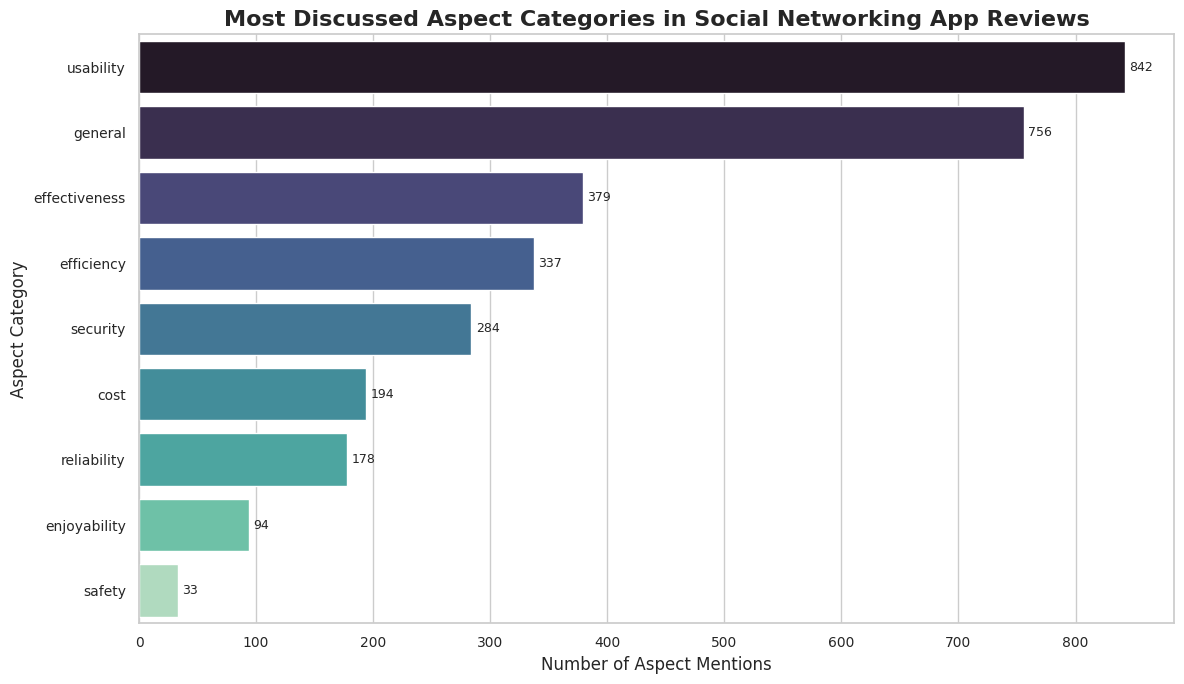

In [ ]:
# This chart shows the most frequently discussed aspects in social networking app reviews.
#
# Assignment usage:
# - Supports ABSA section.
# - Shows whether users discuss usability, effectiveness, security, cost, reliability, etc.

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=aspect_category_summary,
    x="Count",
    y="Aspect Category",
    palette="mako"
)

plt.title("Most Discussed Aspect Categories in Social Networking App Reviews")
plt.xlabel("Number of Aspect Mentions")
plt.ylabel("Aspect Category")

add_bar_labels(ax)

plt.tight_layout()
plt.savefig("visualizations/aspect_category_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# **Aspect Sentiment Distribution Table**

In [ ]:
# This cell summarizes positive and negative aspect-level sentiment.
#
# This is different from rating-based sentiment:
# - rating_sentiment = full review sentiment from rating
# - sentiment = aspect-level sentiment from the dataset labels

aspect_sentiment_summary = (
    aspect_level_df["sentiment"]
    .value_counts()
    .reindex(["positive", "negative"])
    .reset_index()
)

aspect_sentiment_summary.columns = ["Aspect Sentiment", "Count"]

aspect_sentiment_summary["Percentage"] = (
    aspect_sentiment_summary["Count"] / aspect_sentiment_summary["Count"].sum() * 100
).round(2)

aspect_sentiment_summary.to_csv("results/aspect_sentiment_summary.csv", index=False)

aspect_sentiment_summary

,Aspect Sentiment,Count,Percentage
0,positive,1382,44.62
1,negative,1715,55.38


# **Aspect Sentiment Distribution Chart**

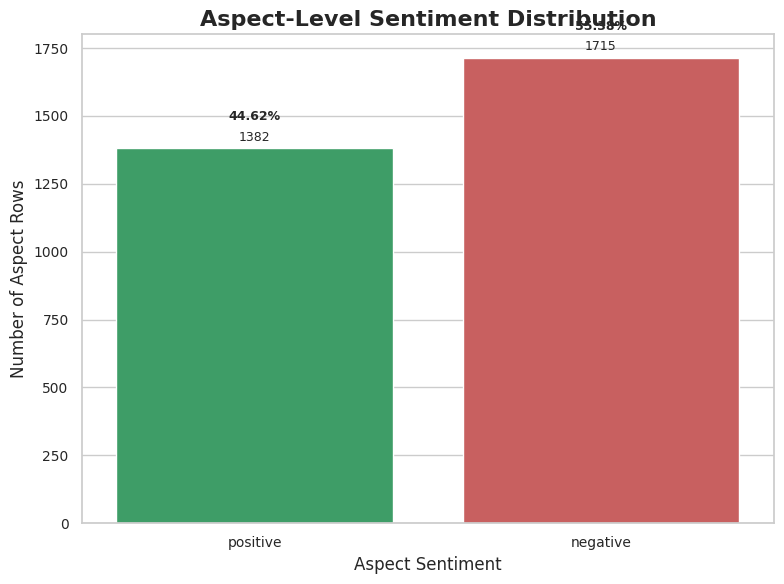

In [ ]:
# This chart shows aspect-level positive and negative sentiment distribution.
#
# Assignment usage:
# - Shows that the ABSA task is more balanced than the rating-based task.
# - Supports the modelling decision in Notebook 2.

plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=aspect_sentiment_summary,
    x="Aspect Sentiment",
    y="Count",
    palette=[
        SENTIMENT_COLORS["positive"],
        SENTIMENT_COLORS["negative"]
    ]
)

plt.title("Aspect-Level Sentiment Distribution")
plt.xlabel("Aspect Sentiment")
plt.ylabel("Number of Aspect Rows")

add_bar_labels(ax)

for i, row in aspect_sentiment_summary.iterrows():
    ax.text(
        i,
        row["Count"] + aspect_sentiment_summary["Count"].max() * 0.06,
        f'{row["Percentage"]}%',
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
plt.savefig("visualizations/aspect_sentiment_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# **Review Length Distribution**

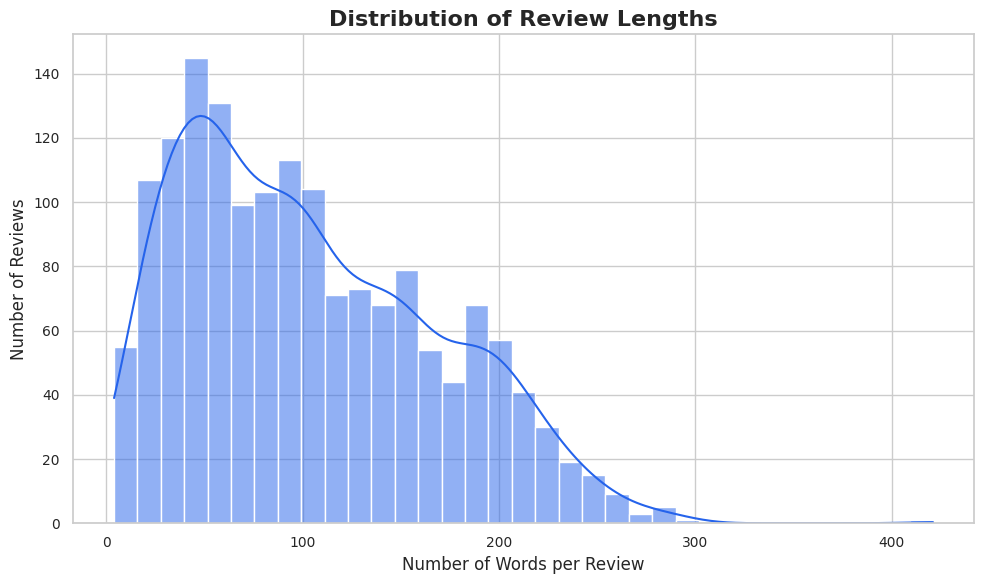

In [ ]:
# This chart shows the distribution of review lengths.
#
# Assignment usage:
# - Supports dataset description and preprocessing discussion.
# - Helps explain whether reviews are short or long.

plt.figure(figsize=(10, 6))

sns.histplot(
    review_level_df["review_word_count"],
    bins=35,
    kde=True,
    color=MAIN_BLUE
)

plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Words per Review")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.savefig("visualizations/review_length_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# **Sentence Length Distribution**

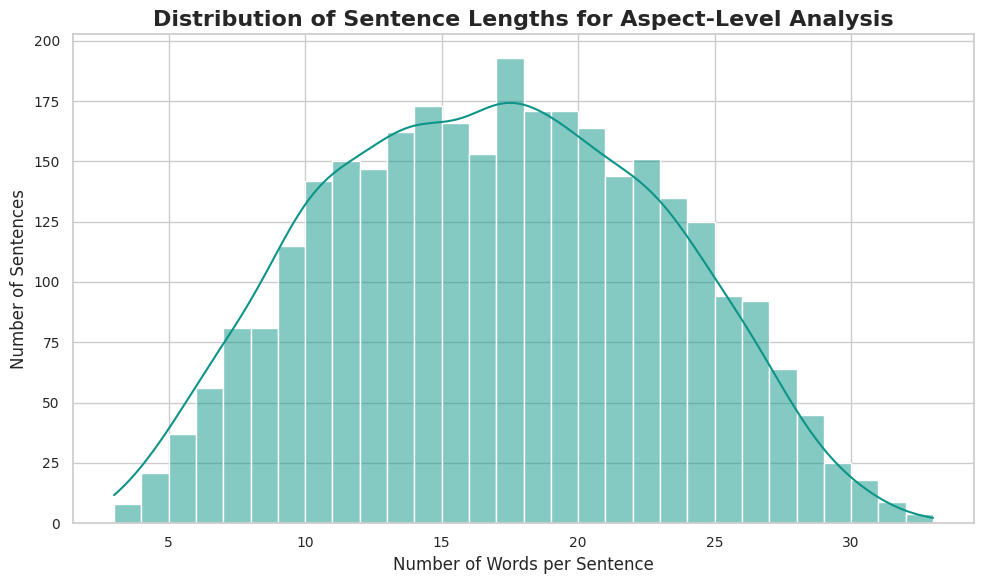

In [ ]:
# This chart shows the distribution of sentence lengths.
#
# Assignment usage:
# - Supports sentence-level analysis and ABSA explanation.
# - Shows that aspect-level modelling uses shorter text units.

plt.figure(figsize=(10, 6))

sns.histplot(
    aspect_level_df["sentence_word_count"],
    bins=30,
    kde=True,
    color=MAIN_TEAL
)

plt.title("Distribution of Sentence Lengths for Aspect-Level Analysis")
plt.xlabel("Number of Words per Sentence")
plt.ylabel("Number of Sentences")

plt.tight_layout()
plt.savefig("visualizations/sentence_length_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# **Aspect Sentiment by Category Table**

In [ ]:
# This cell creates a cross-tabulation of aspect category and aspect sentiment.
#
# This is one of the most important ABSA result tables.
# It shows which app aspects receive more positive or negative sentiment.

aspect_category_sentiment = pd.crosstab(
    aspect_level_df["category"],
    aspect_level_df["sentiment"]
)

# Ensure positive and negative columns exist and are ordered consistently.
for col in ["positive", "negative"]:
    if col not in aspect_category_sentiment.columns:
        aspect_category_sentiment[col] = 0

aspect_category_sentiment = aspect_category_sentiment[["positive", "negative"]]

aspect_category_sentiment["total"] = (
    aspect_category_sentiment["positive"] +
    aspect_category_sentiment["negative"]
)

aspect_category_sentiment = aspect_category_sentiment.sort_values(
    by="total",
    ascending=False
)

aspect_category_sentiment.to_csv("results/aspect_category_sentiment_table.csv")

aspect_category_sentiment

sentiment,positive,negative,total
category,,,
usability,367,475,842
general,405,351,756
effectiveness,179,200,379
efficiency,131,206,337
security,127,157,284
cost,75,119,194
reliability,32,146,178
enjoyability,57,37,94
safety,9,24,33


# **Aspect Sentiment by Category Stacked Bar Chart**

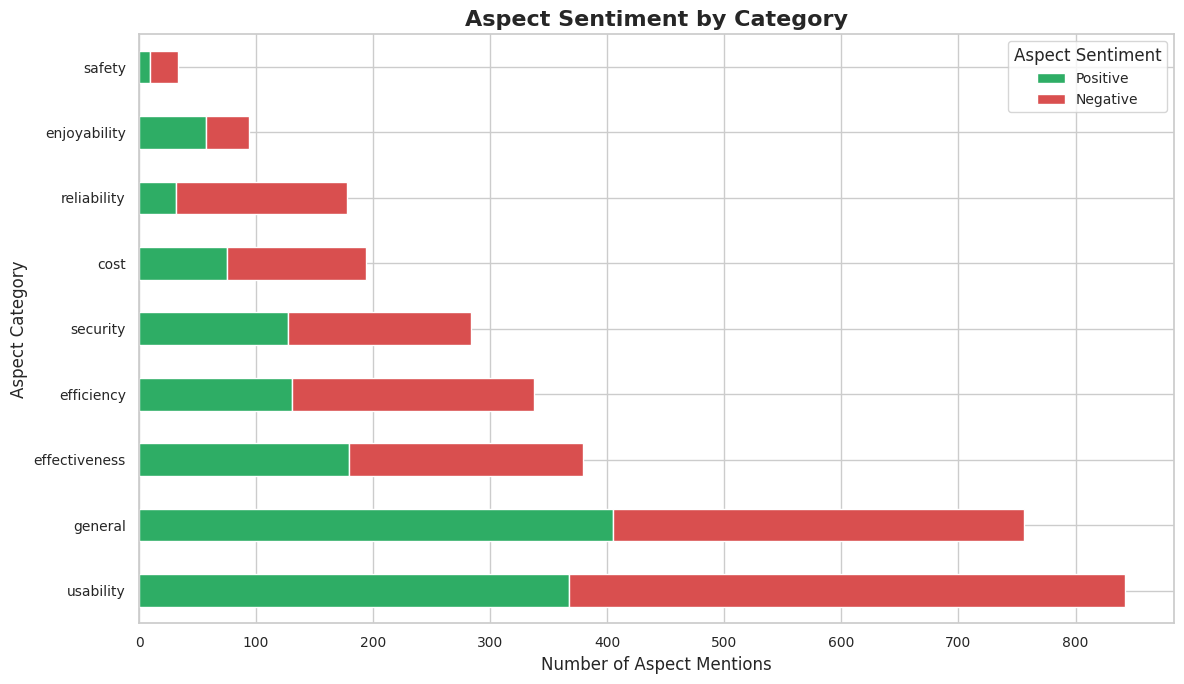

In [ ]:
# This stacked bar chart shows positive and negative sentiment for each aspect category.
#
# Assignment usage:
# - Strong ABSA visualization for Result & Visualization section.
# - Helps identify which aspects cause user satisfaction or dissatisfaction.

plot_df = aspect_category_sentiment[["positive", "negative"]].copy()

plot_df.plot(
    kind="barh",
    stacked=True,
    figsize=(12, 7),
    color=[
        SENTIMENT_COLORS["positive"],
        SENTIMENT_COLORS["negative"]
    ]
)

plt.title("Aspect Sentiment by Category")
plt.xlabel("Number of Aspect Mentions")
plt.ylabel("Aspect Category")
plt.legend(title="Aspect Sentiment", labels=["Positive", "Negative"])

plt.tight_layout()
plt.savefig("visualizations/aspect_sentiment_by_category.png", dpi=300, bbox_inches="tight")
plt.show()

# **Aspect Sentiment Percentage Heatmap**

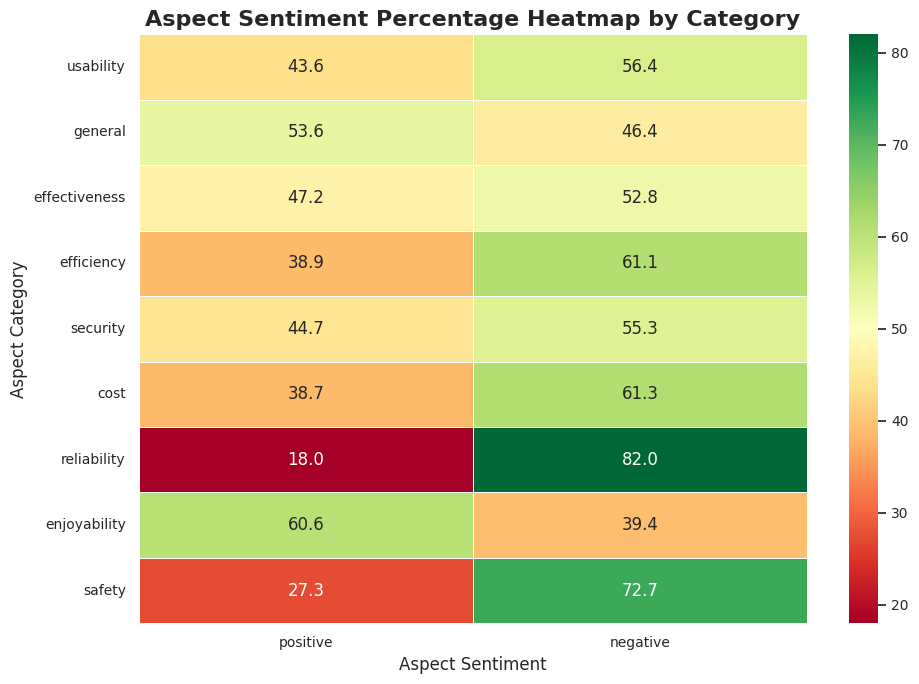

sentiment,positive,negative
category,,
usability,43.59,56.41
general,53.57,46.43
effectiveness,47.23,52.77
efficiency,38.87,61.13
security,44.72,55.28
cost,38.66,61.34
reliability,17.98,82.02
enjoyability,60.64,39.36
safety,27.27,72.73


In [ ]:
# This heatmap shows the percentage of positive and negative sentiment per aspect category.
#
# Assignment usage:
# - Strong visualization for identifying high-risk negative aspects.
# - Useful for Discussion section.

aspect_category_percentage = aspect_category_sentiment[["positive", "negative"]].div(
    aspect_category_sentiment["total"],
    axis=0
) * 100

aspect_category_percentage = aspect_category_percentage.round(2)

plt.figure(figsize=(10, 7))

sns.heatmap(
    aspect_category_percentage,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Aspect Sentiment Percentage Heatmap by Category")
plt.xlabel("Aspect Sentiment")
plt.ylabel("Aspect Category")

plt.tight_layout()
plt.savefig("visualizations/aspect_sentiment_percentage_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

aspect_category_percentage.to_csv("results/aspect_sentiment_percentage_by_category.csv")

aspect_category_percentage

# **Aspect Sentiment by App Table**

In [ ]:
# This cell creates a table of aspect sentiment by app.
#
# Assignment usage:
# - Allows comparison between social networking apps.
# - Supports app-level insight generation in Discussion.

app_sentiment_table = pd.crosstab(
    aspect_level_df["app"],
    aspect_level_df["sentiment"]
)

for col in ["positive", "negative"]:
    if col not in app_sentiment_table.columns:
        app_sentiment_table[col] = 0

app_sentiment_table = app_sentiment_table[["positive", "negative"]]

app_sentiment_table["total"] = (
    app_sentiment_table["positive"] +
    app_sentiment_table["negative"]
)

app_sentiment_table["negative_percentage"] = (
    app_sentiment_table["negative"] / app_sentiment_table["total"] * 100
).round(2)

app_sentiment_table = app_sentiment_table.sort_values(
    by="total",
    ascending=False
)

app_sentiment_table.to_csv("results/app_sentiment_table.csv")

app_sentiment_table

sentiment,positive,negative,total,negative_percentage
app,,,,
whatsapp-messenger,326,325,651,49.92
free-tone-calling-texting,303,344,647,53.17
discord,267,378,645,58.60
facebook,222,364,586,62.12
teamspeak-3,137,243,380,63.95
threema-the-secure-messenger,127,61,188,32.45


# **Aspect Sentiment by App Chart**

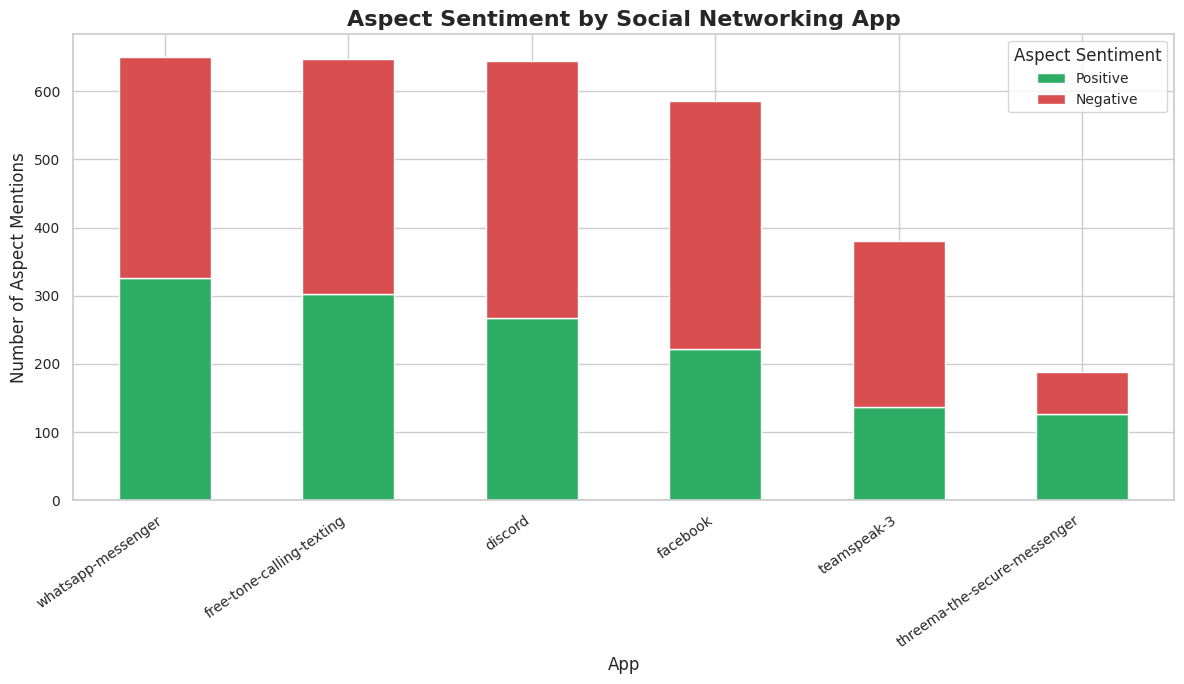

In [ ]:
# This chart compares positive and negative aspect sentiment across apps.
#
# Assignment usage:
# - Useful for showing which social networking apps receive more negative or positive aspect feedback.

app_plot_df = app_sentiment_table[["positive", "negative"]].copy()

app_plot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7),
    color=[
        SENTIMENT_COLORS["positive"],
        SENTIMENT_COLORS["negative"]
    ]
)

plt.title("Aspect Sentiment by Social Networking App")
plt.xlabel("App")
plt.ylabel("Number of Aspect Mentions")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Aspect Sentiment", labels=["Positive", "Negative"])

plt.tight_layout()
plt.savefig("visualizations/aspect_sentiment_by_app.png", dpi=300, bbox_inches="tight")
plt.show()

# **App × Aspect Negative Sentiment Heatmap**

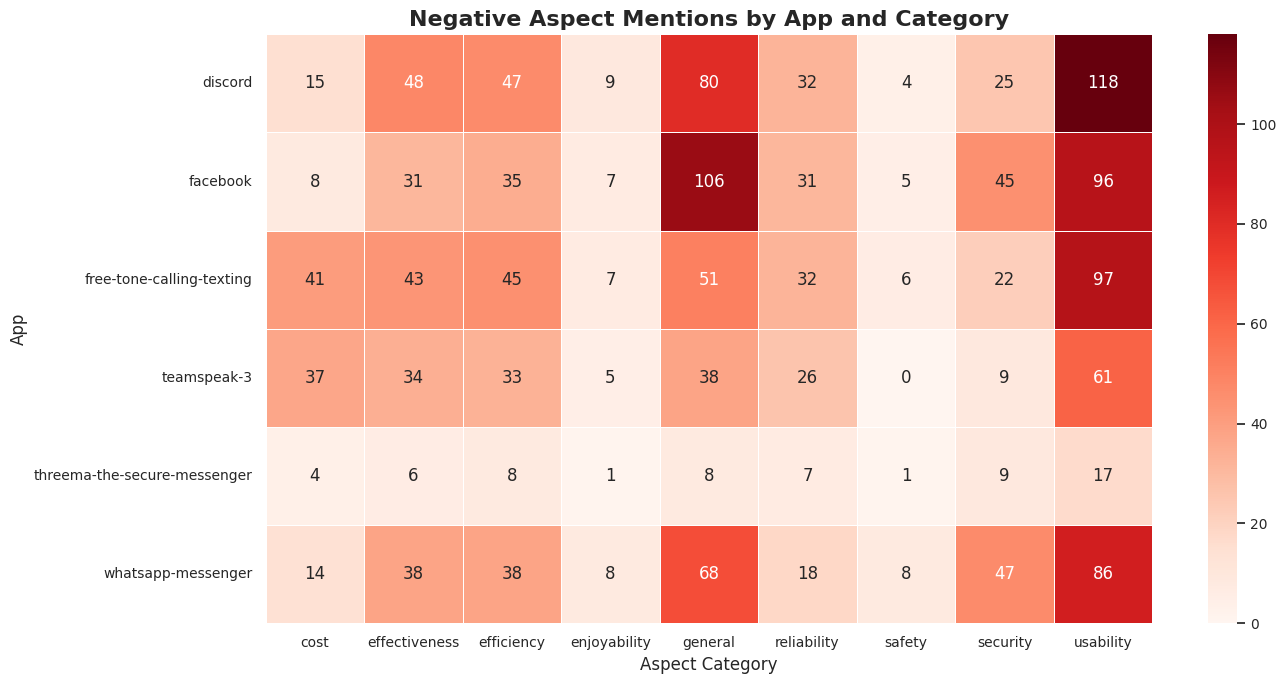

In [ ]:
# This heatmap shows negative sentiment counts across apps and aspect categories.
#
# Assignment usage:
# - Very strong visual for identifying problem areas.
# - Example insight: Facebook may have more reliability complaints, while WhatsApp may have more usability complaints.

negative_aspect_df = aspect_level_df[aspect_level_df["sentiment"] == "negative"]

app_aspect_negative = pd.crosstab(
    negative_aspect_df["app"],
    negative_aspect_df["category"]
)

plt.figure(figsize=(14, 7))

sns.heatmap(
    app_aspect_negative,
    annot=True,
    fmt="d",
    cmap="Reds",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Negative Aspect Mentions by App and Category")
plt.xlabel("Aspect Category")
plt.ylabel("App")

plt.tight_layout()
plt.savefig("visualizations/app_aspect_negative_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

app_aspect_negative.to_csv("results/app_aspect_negative_heatmap_table.csv")

# 6. Notebook 1 Final Export

This section finalizes Notebook 1 by saving the cleaned datasets, EDA summary files, and visualizations.

The exported files will be used in:

1. **Notebook 2** for opinion mining and ABSA insights.
2. **Notebook 3** for model training and evaluation.
3. The final report and PowerPoint presentation.
4. The GitHub/Colab repository appendix.

# **Save Cleaned Datasets**

In [ ]:

# This cell saves the two core datasets created in Notebook 1.
#
# review_level_social_reviews.csv:
# - One row per unique review
# - Used for rating-based document-level sentiment classification
#
# aspect_level_social_reviews.csv:
# - One row per aspect-level sentence/aspect entry
# - Used for opinion mining, ABSA insights, and ABSA model training
# ============================================================

review_level_df.to_csv("results/review_level_social_reviews.csv", index=False)
aspect_level_df.to_csv("results/aspect_level_social_reviews.csv", index=False)

print("Cleaned datasets saved successfully.")
print("1. results/review_level_social_reviews.csv")
print("2. results/aspect_level_social_reviews.csv")

Cleaned datasets saved successfully.
1. results/review_level_social_reviews.csv
2. results/aspect_level_social_reviews.csv


# **Notebook 1 Summary**

In [ ]:
# This cell creates a text summary of Notebook 1 outputs.
#
# Assignment usage:
# - Useful for README
# - Useful for appendix
# - Useful for explaining the dataset preparation process
# ============================================================

notebook1_summary = f"""
CDS6344 GROUP 9 - NOTEBOOK 1 SUMMARY

Cleaned Full Dataset Shape:
{df_clean.shape}

Review-Level Dataset Shape:
{review_level_df.shape}

Aspect-Level Dataset Shape:
{aspect_level_df.shape}

Review-Level Rating Distribution:
{review_level_df['rating'].value_counts().sort_index().to_string()}

Review-Level Rating-Based Sentiment Distribution:
{review_level_df['rating_sentiment'].value_counts().to_string()}

Aspect-Level Sentiment Distribution:
{aspect_level_df['sentiment'].value_counts().to_string()}

Aspect Category Distribution:
{aspect_level_df['category'].value_counts().to_string()}

Files Created:
- results/review_level_social_reviews.csv
- results/aspect_level_social_reviews.csv
- EDA summary CSV files in results/
- EDA visualizations in visualizations/

Notebook 1 Use:
- Dataset description
- Data cleaning and preprocessing explanation
- Rating-based sentiment label creation
- Exploratory data analysis
- Initial result visualizations
- Input files for Notebook 2 and Notebook 3
"""

with open("results/notebook1_summary.txt", "w", encoding="utf-8") as f:
    f.write(notebook1_summary)

print(notebook1_summary)
print("Notebook 1 summary saved as results/notebook1_summary.txt")


CDS6344 GROUP 9 - NOTEBOOK 1 SUMMARY

Cleaned Full Dataset Shape:
(3097, 21)

Review-Level Dataset Shape:
(1615, 10)

Aspect-Level Dataset Shape:
(3097, 20)

Review-Level Rating Distribution:
rating
1    396
2    155
3    260
4    313
5    491

Review-Level Rating-Based Sentiment Distribution:
rating_sentiment
Positive    804
Negative    551
Neutral     260

Aspect-Level Sentiment Distribution:
sentiment
negative    1715
positive    1382

Aspect Category Distribution:
category
usability        842
general          756
effectiveness    379
efficiency       337
security         284
cost             194
reliability      178
enjoyability      94
safety            33

Files Created:
- results/review_level_social_reviews.csv
- results/aspect_level_social_reviews.csv
- EDA summary CSV files in results/
- EDA visualizations in visualizations/

Notebook 1 Use:
- Dataset description
- Data cleaning and preprocessing explanation
- Rating-based sentiment label creation
- Exploratory data analysis

# **ZIP Notebook 1 Outputs**

In [ ]:
# This cell compresses Notebook 1 results and visualizations.
#
# Assignment usage:
# - Download and keep this ZIP for report, slides, GitHub, and the next notebooks.
# ============================================================

zip_path = "exports/CDS6344_Group9_Notebook1_Outputs.zip"

with zipfile.ZipFile(zip_path, "w") as zipf:
    for folder in ["results", "visualizations"]:
        for root, dirs, files_in_folder in os.walk(folder):
            for file in files_in_folder:
                file_path = os.path.join(root, file)
                zipf.write(file_path)

print("Notebook 1 outputs zipped successfully:")
print(zip_path)

Notebook 1 outputs zipped successfully:
exports/CDS6344_Group9_Notebook1_Outputs.zip


# **Download Notebook 1 ZIP**

In [ ]:
# This cell downloads Notebook 1 outputs.
# Keep this ZIP safely because it will be used in the report, slides, and next notebooks.

from google.colab import files

files.download("exports/CDS6344_Group9_Notebook1_Outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>